# In this notebook we are going to be analyzing and clustering the personality of customers

In [65]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import missingno as missing
import math

## First we are going to look into the data itself to see what we"re working with

In [66]:
dataset = pd.read_csv("./dataset/marketing_campaign.csv", sep="\t")
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Attributes

### People

- ID: Customer"s unique identifier
- Year_Birth: Customer"s birth year
- Education: Customer"s education level
- Marital_Status: Customer"s marital status
- Income: Customer"s yearly household income
- Kidhome: Number of children in customer"s household
- Teenhome: Number of teenagers in customer"s household
- Dt_Customer: Date of customer"s enrollment with the company
- Recency: Number of days since customer"s last purchase
- Complain: 1 if the customer complained in the last 2 years, 0 otherwise

### Products

- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years

### Promotion

- NumDealsPurchases: Number of purchases made with a discount
- AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

### Place

- NumWebPurchases: Number of purchases made through the company’s website
- NumCatalogPurchases: Number of purchases made using a catalogue
- NumStorePurchases: Number of purchases made directly in stores
- NumWebVisitsMonth: Number of visits to company’s website in the last month

In [67]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

<Axes: >

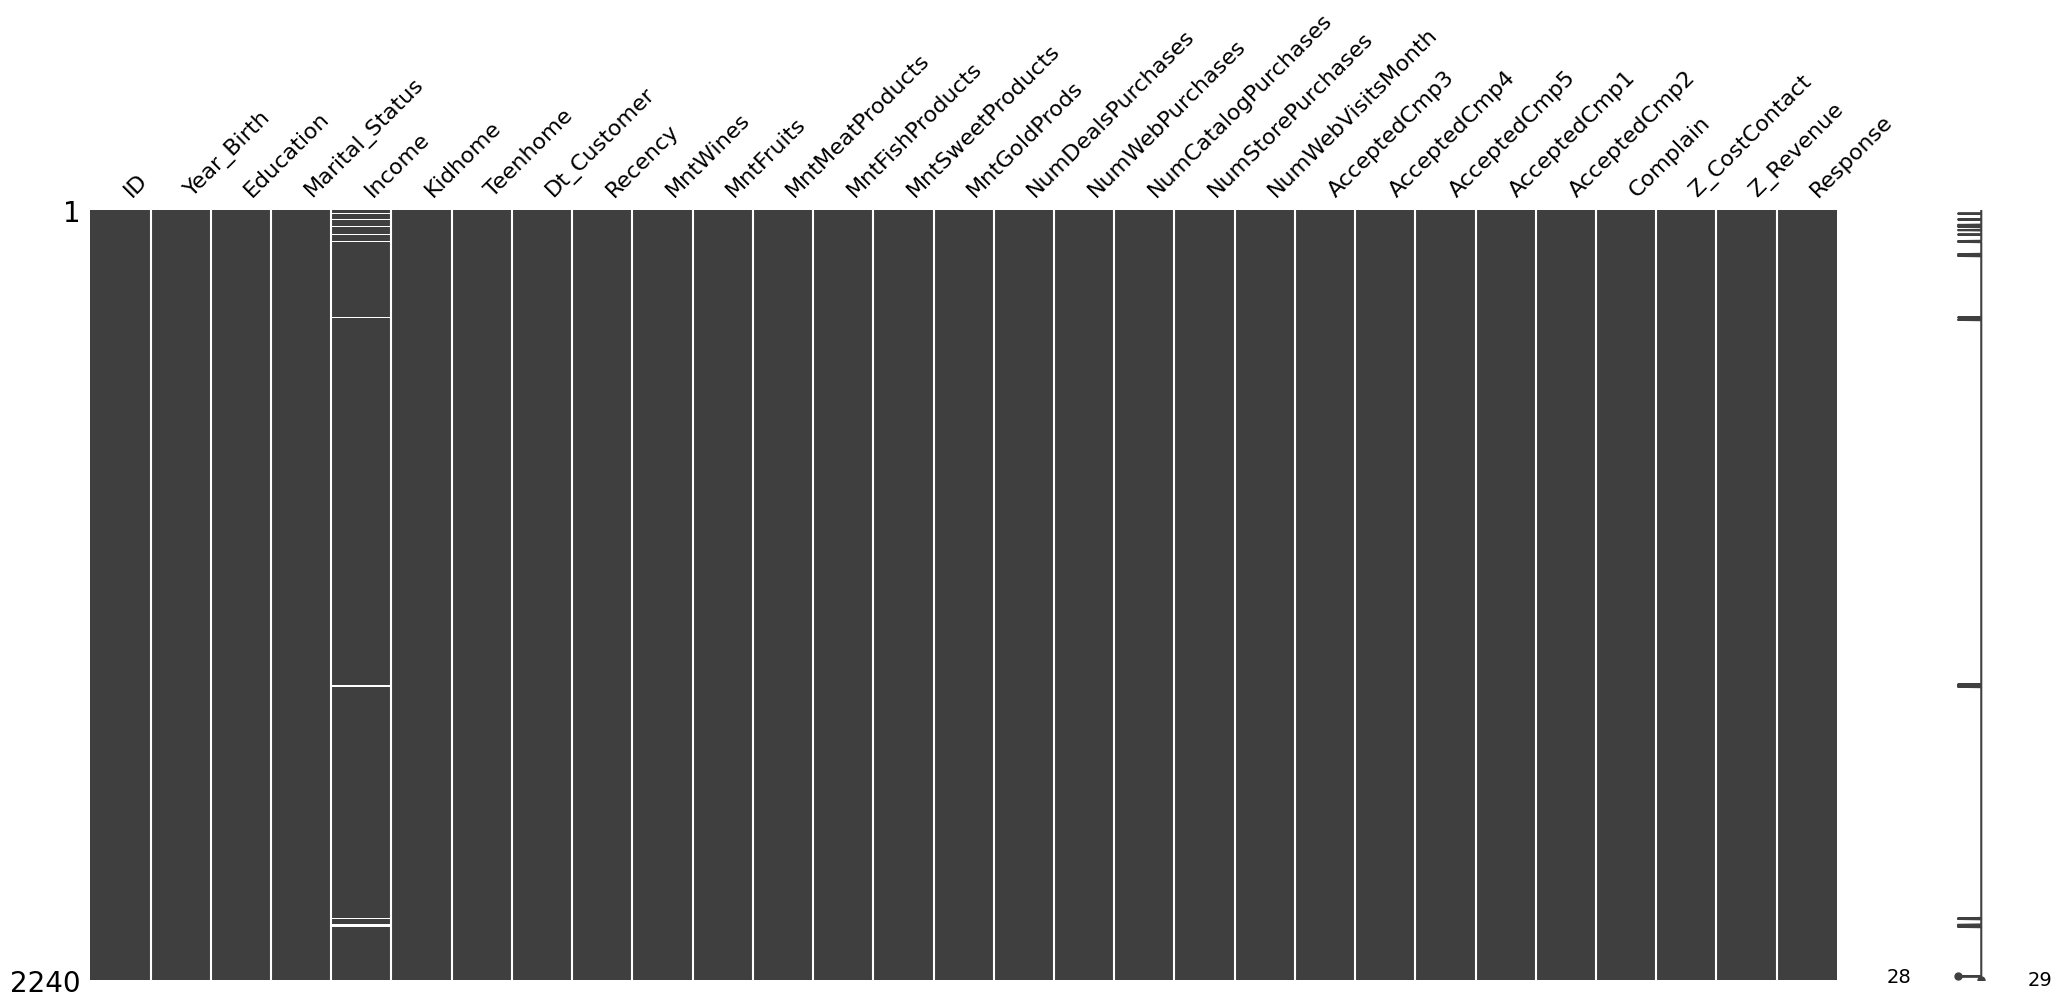

In [68]:
missing.matrix(dataset)

<Axes: >

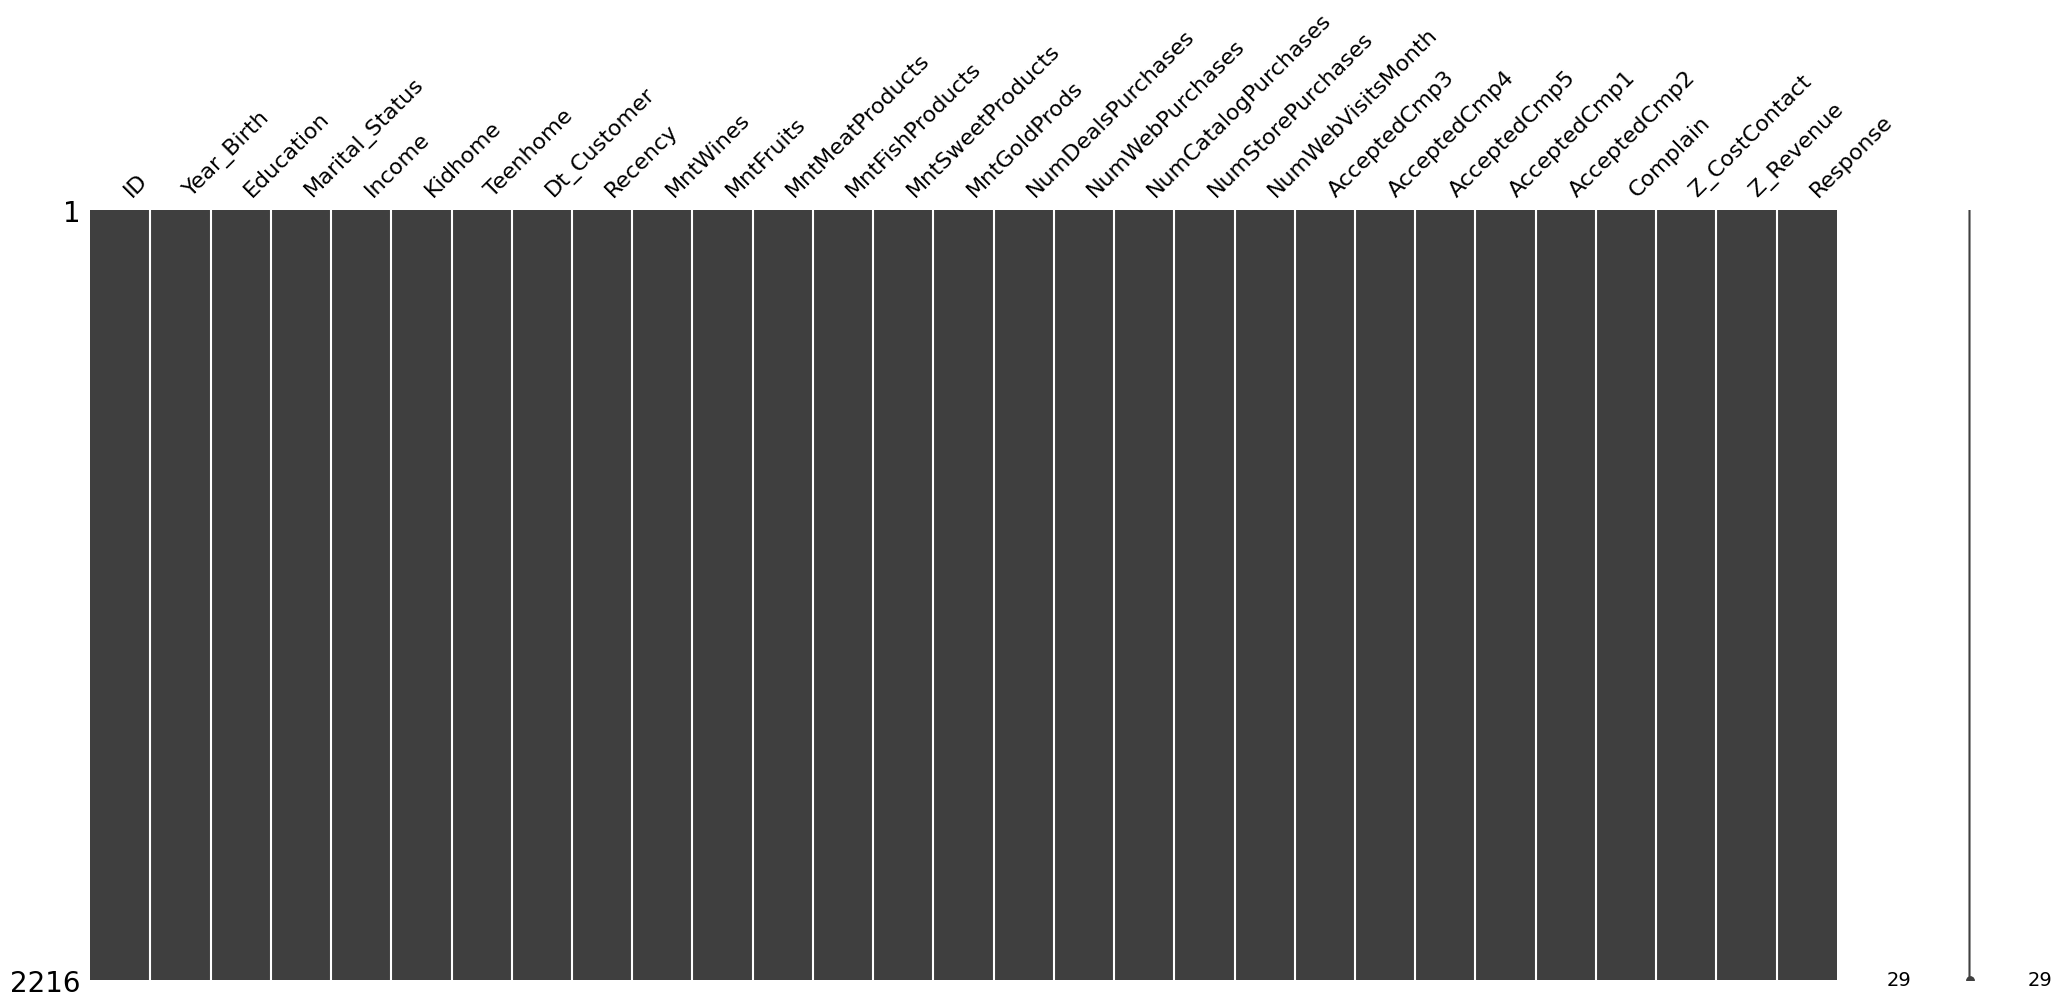

In [69]:
# We can see here that there are some missing values in the dataset, but they are not significant. We can drop them without losing much information.
dataset.dropna(inplace=True)
missing.matrix(dataset)

In [70]:
dataset.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [71]:
# We note here that Dt_customer is a date column, we can convert it to datetime format, we can also make an "age" column by subtracting the year of birth from the year of enrollment.
# We can also make a "children" column by adding the number of kids and teens together.
dataset["Children"] = dataset["Kidhome"] + dataset["Teenhome"]
dataset["Dt_Customer"] = pd.to_datetime(dataset["Dt_Customer"], dayfirst=True)
dataset["Age_at_enrollment"] = dataset["Dt_Customer"].dt.year - dataset["Year_Birth"]
dataset.Dt_Customer.dtypes.name

'datetime64[ns]'

In [72]:
dataset[["Age_at_enrollment","Children"]].describe()

,Age_at_enrollment,Children
count,2216.000000,2216.000000
mean,44.208032,0.947202
std,12.023812,0.749062
min,16.000000,0.000000
25%,36.000000,0.000000
50%,43.000000,1.000000
75%,54.000000,1.000000
max,121.000000,3.000000


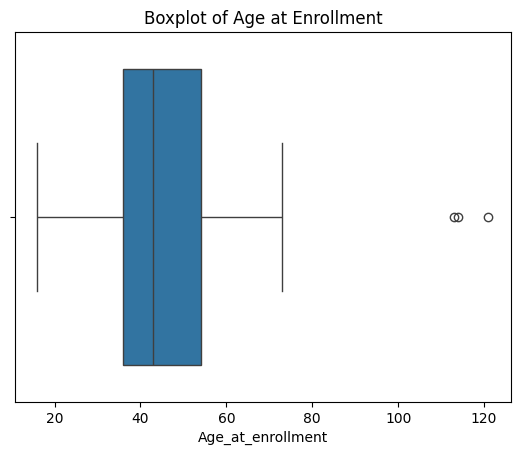

In [73]:
# As we can see in the table above, the average age is about 44 years old, the number of children about 1 and the maximum age at 121 seems unlikely, we can check the data to see if there are any outliers in the age column.
sns.boxplot(x=dataset["Age_at_enrollment"])
plt.title("Boxplot of Age at Enrollment")
plt.show()

In [74]:
# There are some outliers in the age column, we can check the data to see if there are any customers with age greater than 100 and less than 16, we can drop them as they are unlikely to be real customers.
outliers = dataset[(dataset["Age_at_enrollment"] > 100) | (dataset["Age_at_enrollment"] < 16)]
outliers.Age_at_enrollment

192    113
239    121
339    114
Name: Age_at_enrollment, dtype: int64

<Axes: xlabel='Age_at_enrollment'>

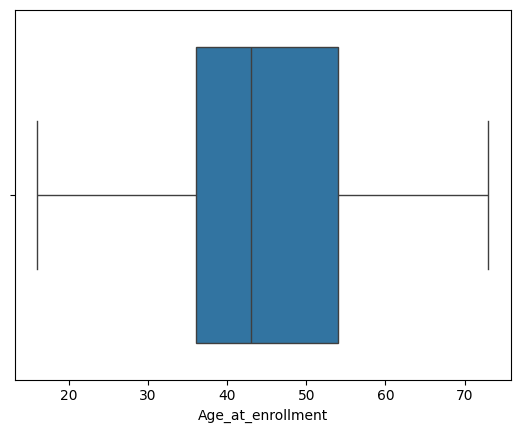

In [75]:
# There are few of them and they are unlikely to be real customers, we can drop them from the dataset.
dataset = dataset[(dataset["Age_at_enrollment"] <= 100) & (dataset["Age_at_enrollment"] >= 16)]
sns.boxplot(x=dataset["Age_at_enrollment"])

<Axes: xlabel='Income'>

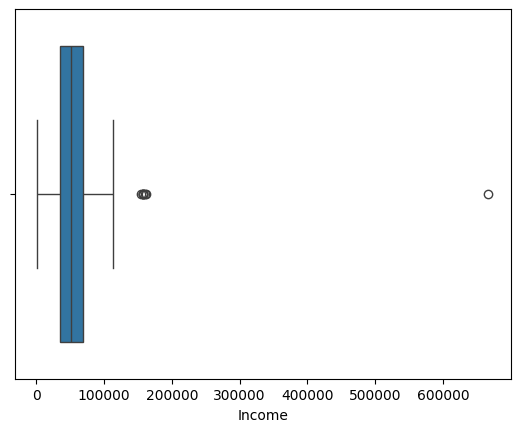

In [76]:
dataset["Income"].describe()
sns.boxplot(x=dataset["Income"])

In [77]:
outliers = dataset[(dataset["Income"] > 400000) | (dataset["Income"] < 1000)]
outliers.Income

2233    666666.0
Name: Income, dtype: float64

<Axes: xlabel='Income'>

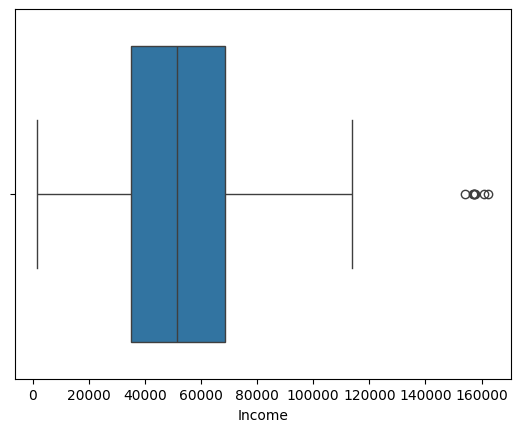

In [78]:
dataset = dataset[(dataset["Income"] <= 400000) & (dataset["Income"] >= 1000)]
sns.boxplot(x=dataset["Income"])

<Axes: xlabel='Income', ylabel='Count'>

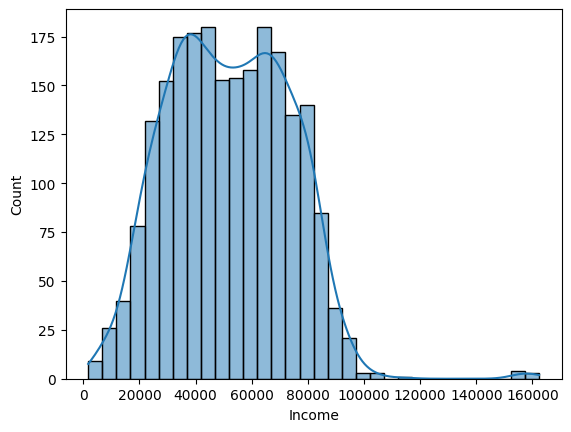

In [79]:
sns.histplot(x=dataset["Income"], kde=True)

<Axes: xlabel='Age_at_enrollment', ylabel='Count'>

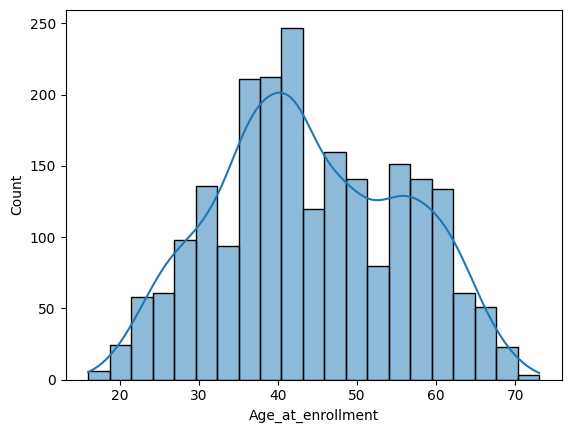

In [80]:
sns.histplot(x=dataset["Age_at_enrollment"], kde=True)

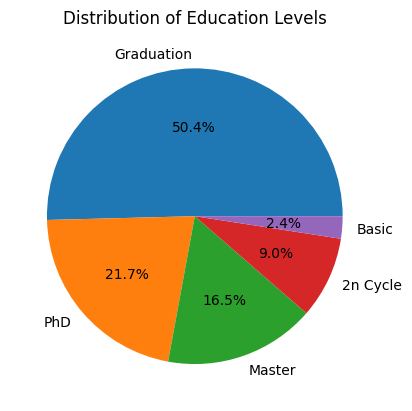

In [81]:
education_counts = dataset["Education"].value_counts()

plt.figure()
plt.pie(education_counts, labels=education_counts.index, autopct="%1.1f%%")

plt.title("Distribution of Education Levels")
plt.show()

In [82]:
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
dataset["Total_Spending"] = dataset[spending_cols].sum(axis=1)
dataset["Total_Spending"].describe()

count    2212.000000
mean      607.268083
std       602.513364
min         5.000000
25%        69.000000
50%       397.000000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64

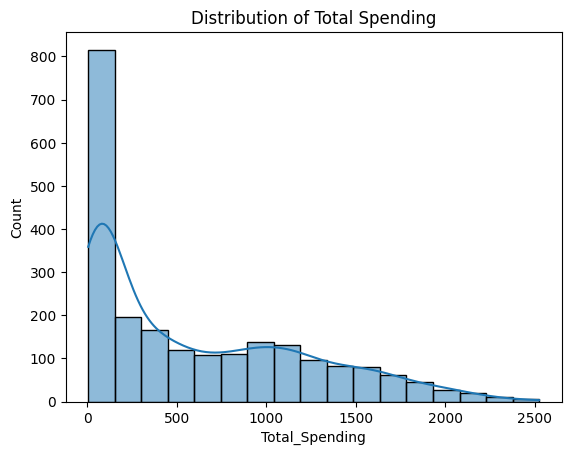

In [83]:
sns.histplot(x=dataset["Total_Spending"], kde=True)
plt.title("Distribution of Total Spending")
plt.show()

In [84]:
dataset["Recency"].describe()

count    2212.000000
mean       49.019439
std        28.943121
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

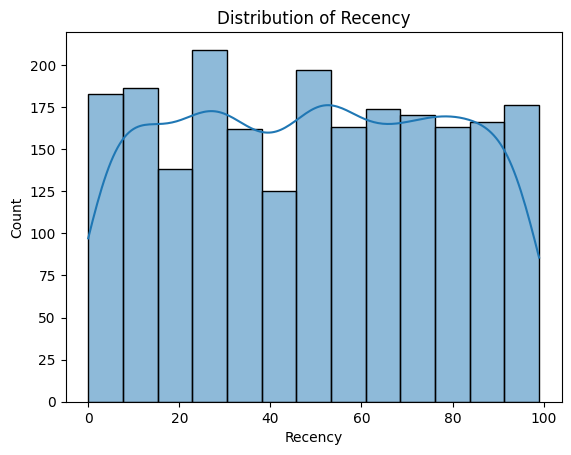

In [85]:
sns.histplot(x=dataset["Recency"], kde=True)
plt.title("Distribution of Recency")
plt.show()

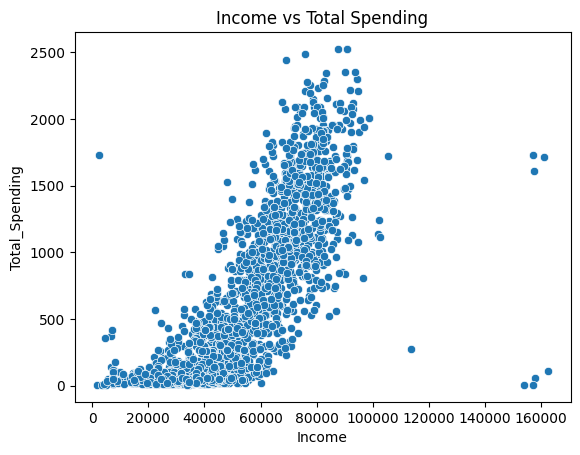

In [86]:
sns.scatterplot(x=dataset["Income"], y=dataset["Total_Spending"])
plt.title("Income vs Total Spending")
plt.show()

As expected we can observe a very clear relation between total spending and income in most cases

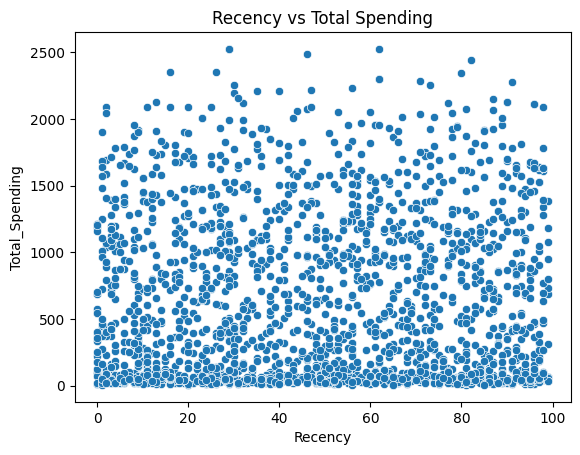

In [87]:
sns.scatterplot(x=dataset["Recency"], y=dataset["Total_Spending"])
plt.title("Recency vs Total Spending")
plt.show()


Sadly there does not seem to be any clear relation between Active spenders and how much they spend in total

In [88]:
def plot_scatter_grid(dataset, pairs, cols=3, fig_width=6, fig_height=5):
    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width * cols, fig_height * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for ax, (x_col, y_col) in zip(axes, pairs):
        sns.scatterplot(x=dataset[x_col], y=dataset[y_col], ax=ax)
        ax.set_title(f"{x_col} vs {y_col}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    # Hide unused axes if pairs don"t fill the grid
    for ax in axes[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

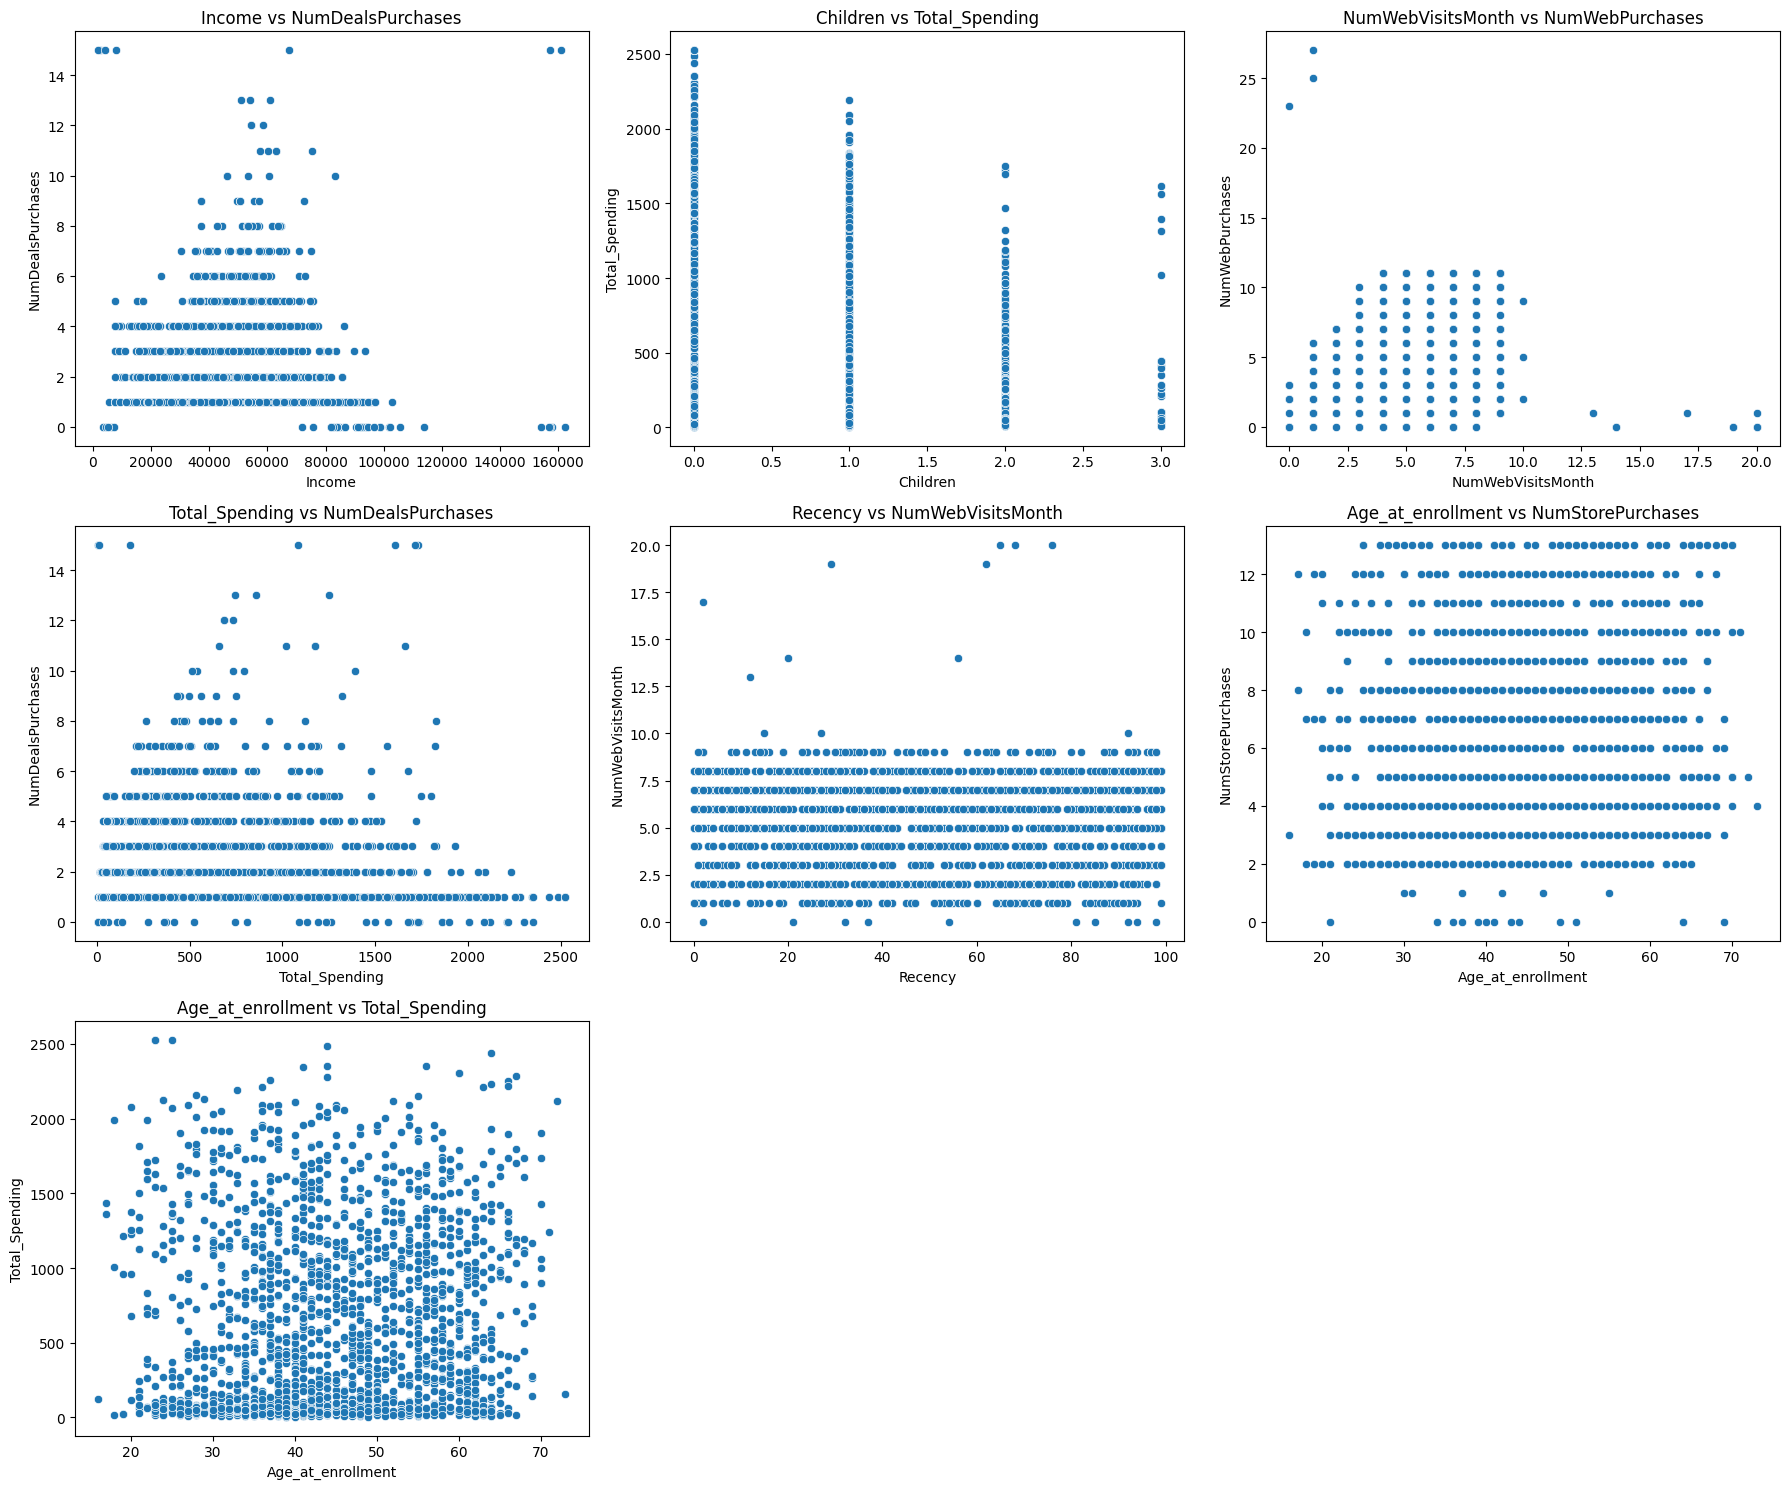

In [89]:
pairs = [
    ("Income", "NumDealsPurchases"),              # Deal sensitivity by income
    ("Children", "Total_Spending"),               # Household composition effect
    ("NumWebVisitsMonth", "NumWebPurchases"),     # Web conversion ratio
    ("Total_Spending", "NumDealsPurchases"),      # Deal-seekers vs high-value customers
    ("Recency", "NumWebVisitsMonth"),             # Recency vs Web activity
    ("Age_at_enrollment", "NumStorePurchases"),   # Channel preference by age
    ("Age_at_enrollment", "Total_Spending")       # Total spending vs Age
]

plot_scatter_grid(dataset, pairs, cols=3)

We can see some obvious relations between some variables but in many others there is no clear correlation

In [90]:
purchase_location_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
dataset["Total_Purchases"] = dataset[purchase_location_cols].sum(axis=1)
dataset["Total_Purchases"].describe()

count    2212.000000
mean       12.566908
std         7.205427
min         0.000000
25%         6.000000
50%        12.000000
75%        18.250000
max        32.000000
Name: Total_Purchases, dtype: float64

In [91]:
for col in purchase_location_cols:
    dataset[col + "_ratio"] = dataset[col] / dataset["Total_Purchases"]
dataset = dataset[dataset["Total_Purchases"] > 0]

<Axes: xlabel='NumWebPurchases_ratio', ylabel='NumStorePurchases_ratio'>

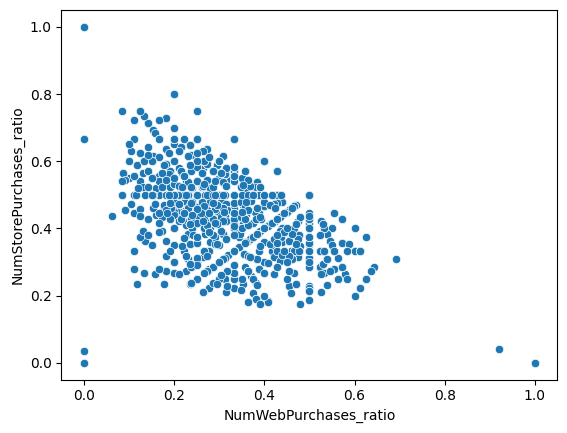

In [92]:
sns.scatterplot(
    data=dataset,
    x="NumWebPurchases_ratio",
    y="NumStorePurchases_ratio"
)

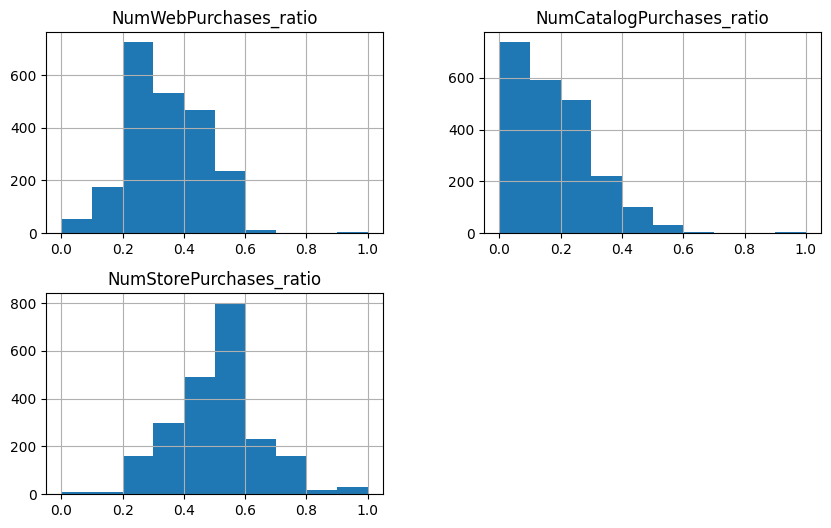

In [93]:
dataset[[col + "_ratio" for col in purchase_location_cols]].hist(figsize=(10,6))
plt.show()

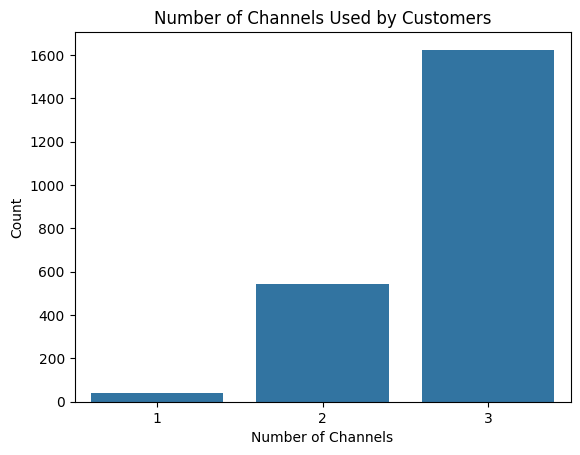

In [94]:
dataset["ChannelsUsed"] = (dataset[purchase_location_cols] > 0).sum(axis=1)
sns.countplot(x=dataset["ChannelsUsed"])
plt.title("Number of Channels Used by Customers")
plt.xlabel("Number of Channels")
plt.ylabel("Count")
plt.show()

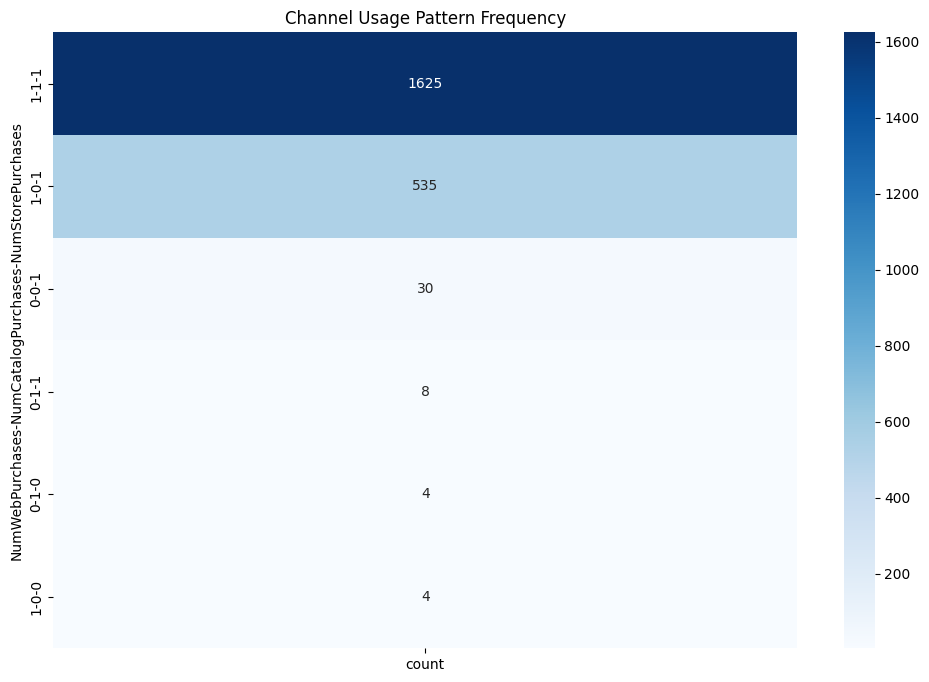

In [95]:
pattern = (dataset[purchase_location_cols] > 0).astype(int)

pattern_counts = pattern.value_counts().reset_index()
pattern_counts["count"] = pattern_counts.iloc[:, len(purchase_location_cols):].sum(axis=1)

heatmap_data = pattern_counts.set_index(purchase_location_cols)["count"].to_frame()

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Channel Usage Pattern Frequency")
plt.show()

In [96]:
campaign_cols = [
    "AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
    "AcceptedCmp4","AcceptedCmp5"
]

dataset["TotalAcceptedCmp"] = dataset[campaign_cols].sum(axis=1)
dataset[campaign_cols + ["Response"]].mean()

AcceptedCmp1    0.064370
AcceptedCmp2    0.013599
AcceptedCmp3    0.073889
AcceptedCmp4    0.074343
AcceptedCmp5    0.072983
Response        0.150952
dtype: float64

<Axes: xlabel='Response', ylabel='Income'>

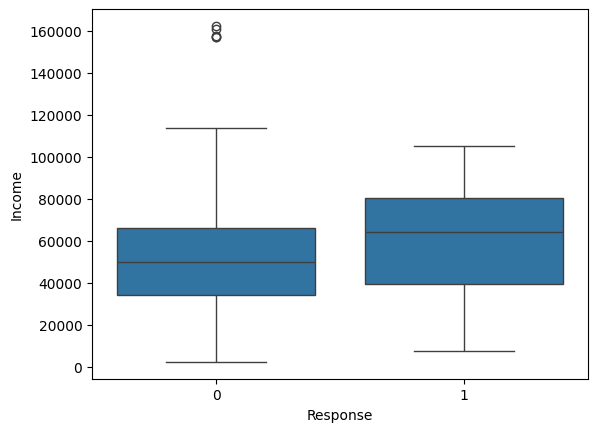

In [97]:
sns.boxplot(x="Response", y="Income", data=dataset)

<Axes: xlabel='Response', ylabel='Total_Spending'>

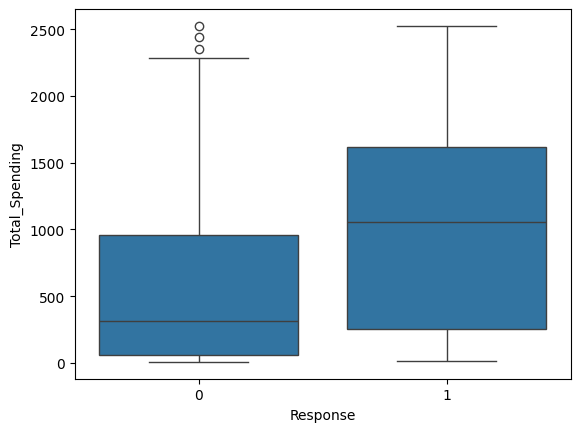

In [98]:
sns.boxplot(x="Response", y="Total_Spending", data=dataset)

In [99]:
dataset["Income_bin"] = pd.qcut(dataset["Income"], 4)

pd.crosstab(dataset["Income_bin"], dataset["Response"], normalize="index")

Response,0,1
Income_bin,,
"(2446.999, 35352.0]",0.894928,0.105072
"(35352.0, 51381.5]",0.874773,0.125227
"(51381.5, 68480.75]",0.896552,0.103448
"(68480.75, 162397.0]",0.730072,0.269928


<Axes: >

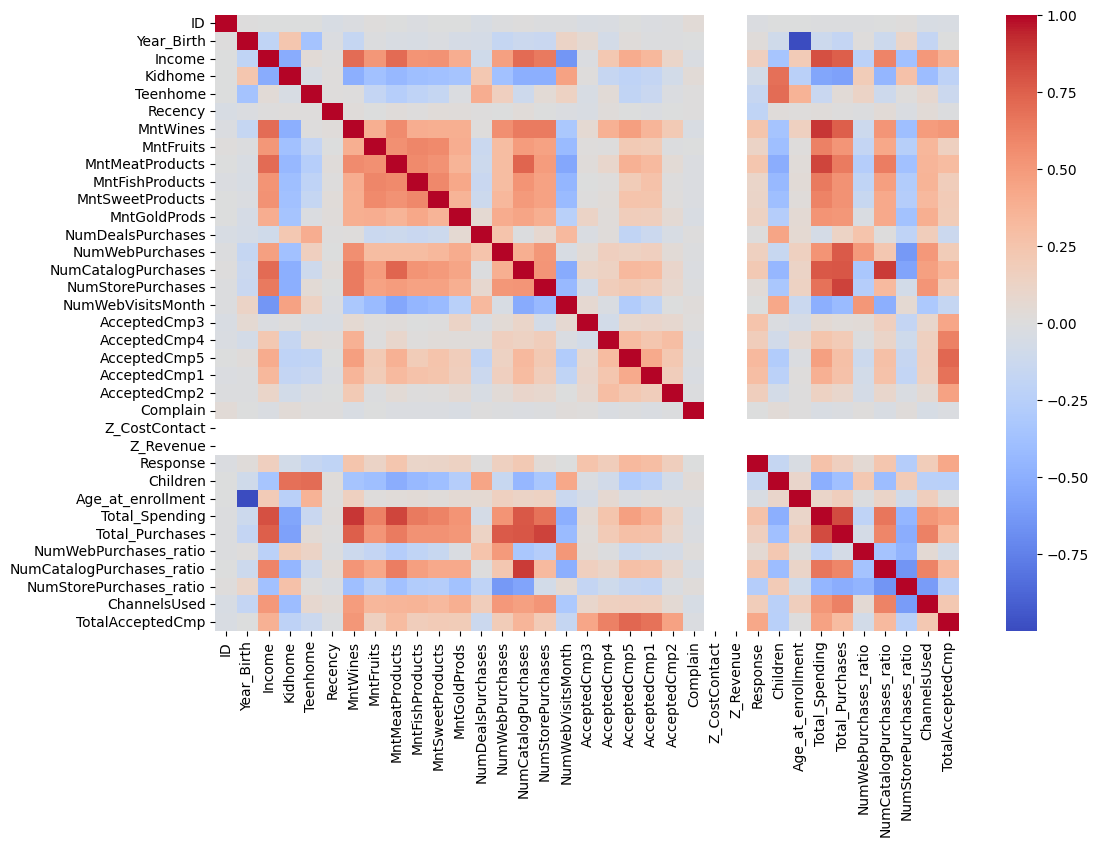

In [100]:
corr = dataset.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")

In [101]:
edu_map = {
    "Basic": 0,
    "Graduation": 1,
    "Master": 2,
    "PhD": 3
}
dataset["Education_Ordinal"] = dataset["Education"].map(edu_map)
dataset["Is_Partnered"] = dataset["Marital_Status"].isin(["Married", "Together"]).astype(int)

<Axes: >

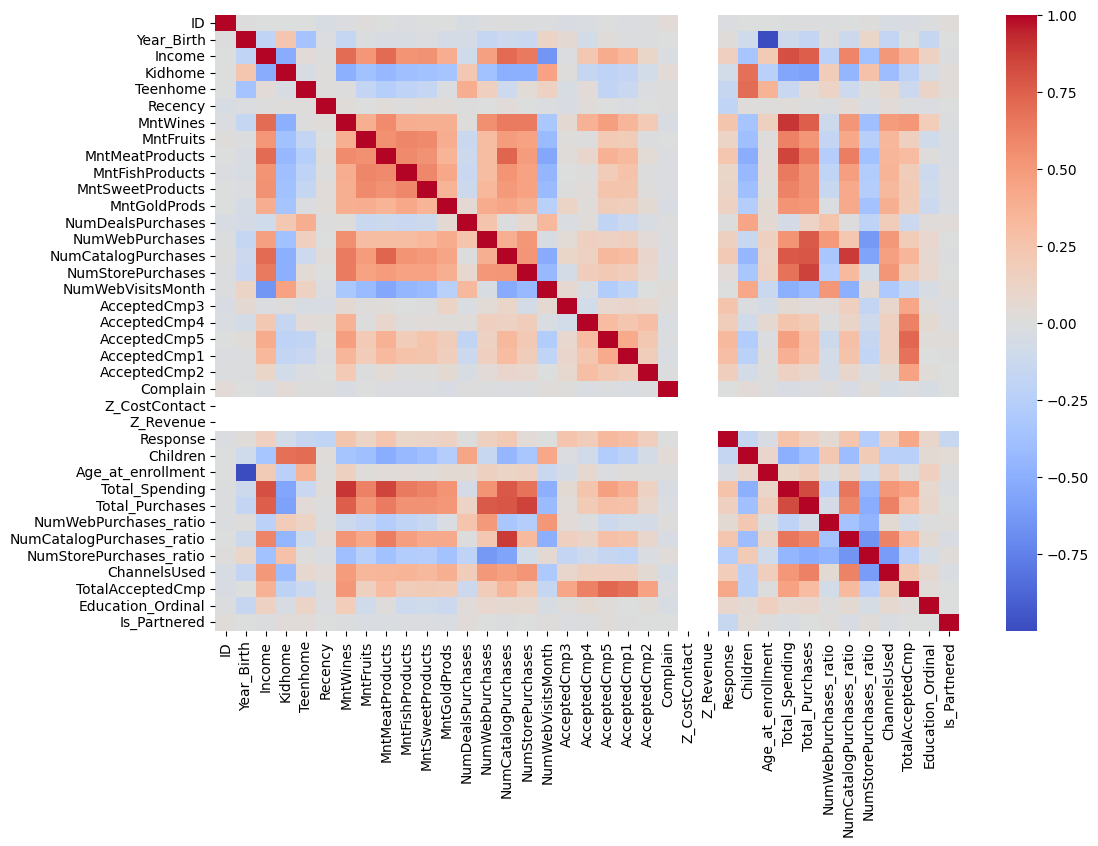

In [102]:
corr = dataset.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")